# Aimsun Replication Data Extractor
Extract per-replication results from an Aimsun SQLite output database.
Run the **Inspect** cell first to see what replications are available, then configure and run **Extract → Save**.

In [31]:
# Path to the Aimsun SQLite output database
SQLITE_FILE = r"C:\Users\IvanVelilla\Mobility Lab Limited\Projects - 1034 - Western LX Aimsun\New North Road\Model\v10\Resources\Outputs\ADTA_NNR_WesternLX_v10.sqlite"

# Output Excel file path
OUTPUT_FILE = r"C:\Users\IvanVelilla\Documents\Projects\Western LX\outputs\replication_extract.xlsx"

# Replication DIDs to extract. Run the Inspect cell first to see available IDs.
# Set to None or [] to extract ALL replications (type=1).
REPLICATION_DIDS = None  # e.g. [89345926, 89345925, 89345924]

# Table(s) to extract from — a single string or a list for multiple tables.
# Supported:  "MISUBPATH", "MISECT", "MIDETEC", "MILANE", "MINODE", "MISYS", "MITURN"
# TABLES = "MISUBPATH"               # single table
TABLES = ["MISUBPATH", "MISYS"]  # multiple tables simultaneously

# Filter rows to specific integer OIDs (applies to every table in TABLES).
# Set to None for all objects.
OID_FILTER = None  # e.g. [89336739, 89336740]

# Filter rows to specific external ID strings (the eid column).
# For MISUBPATH these are subpath group names e.g. "2025 Base", "2025 Option 1".
# Set to None for all. Can be combined with OID_FILTER.
EID_FILTER = None  # e.g. ["2025 Base"]

# Vehicle type filter: 0 = all vehicles combined. None = include every sid.
SID_FILTER = [0]

# ent=0 is the full simulation-period summary; ent=1–N are 15-min intervals.
# True  → summary rows only (faster, smaller output)
# False → all intervals including summary (needed for time-series plots)
SUMMARY_ONLY = False

# ── Plotting ──────────────────────────────────────────────────────────────────
# Each entry in PLOT_CONFIGS produces one figure.
# Keys per entry:
#   "table"       — which extracted table to plot (must be in TABLES above)
#   "metric"      — column to plot (check printed Columns after Extract)
#   "dids"        — list of replication DIDs to include, or None for all extracted
#   "eids"        — list of eid strings to filter objects, or None for all
#   "experiments" — list of experiment names to include, or None for all
#
# Layout is automatic:
#   MISUBPATH / MISECT etc. → one subplot per unique OID
#   MISYS (where oid == did) → one subplot total, all reps as separate series
#
# Common metrics by table:
#   MISUBPATH : "ttime_min", "dtime_min", "speed", "count", "flow"
#   MISYS     : "ttime_min", "dtime_min", "speed", "flow", "density"
#   MISECT    : "flow", "count", "speed", "density", "ttime_min"
#   MIDETEC   : "countveh", "flow", "speed", "occupancy", "headway"
#   MINODE    : "approachDelay_min", "lostVehicles"
#   MILANE    : "flow", "speed", "density", "ttime_min"
#   MITURN    : "flow", "count", "ttime_min", "speed"

PLOT_CONFIGS = [
    {
        "table":       "MISUBPATH",
        "metric":      "ttime_min",
        "dids":        None,
        "eids":        ["2025 Base"],
        "experiments": ["2025 Base AM"],
    },
    {
        "table":       "MISUBPATH",
        "metric":      "ttime_min",
        "dids":        None,
        "eids":        ["2025 Base"],
        "experiments": ["2025 Base PM"],
    },
    {
        "table":       "MISYS",
        "metric":      "vWait",
        "dids":        None,
        "eids":        None,
        "experiments": ["2025 Base AM"],
    },
    {
        "table":       "MISYS",
        "metric":      "vWait",
        "dids":        None,
        "eids":        None,
        "experiments": ["2025 Base PM"],
    },
]

# Optional labels for OIDs — shared across all plot configs.
# Keys are OID integers; values are display name strings.
PLOT_OID_LABELS = {
    89336741: "Blockhouse Bay Rd NB",
    89336739: "New North Road NB",
    89336740: "New North Road SB",
    89336752: "Morningside NB",
    89336753: "Morningside SB",
    89336746: "Richardson Road EB",
    89336744: "Richardson Road WB",
    89361021: "Saint Georges Road NB",
    89361022: "Saint Georges Road SB",
    89336754: "Sandringham NB",
    89336755: "Sandringham SB",
    89336747: "Mount Albert Rd EB",
    89336749: "Mount Albert Rd WB",
    89336750: "St Lukes Rd EB",
    89336751: "St Lukes Rd WB",
    89362303: "Great North Road EB",
    89362304: "Great North Road WB",
}  # e.g. {89336739: "New North Road NB"}

In [32]:
import sqlite3
import numpy as np
import pandas as pd

print("Ready.")

Ready.


## Inspect — run this first to see available replications

In [33]:
def _fmt_time(seconds):
    h, rem = divmod(int(seconds), 3600)
    m = rem // 60
    return f"{h:02d}:{m:02d}"

con = sqlite3.connect(SQLITE_FILE)
all_reps = pd.read_sql(
    """
    SELECT did, didname, type,
           xname  AS experiment,
           scname AS scenario,
           seed, twhen AS date,
           from_time, duration,
           exec_date
    FROM SIM_INFO
    WHERE type = 1
    ORDER BY xname, did
    """,
    con,
)
con.close()

all_reps["start_time"]  = all_reps["from_time"].apply(_fmt_time)
all_reps["duration_hr"] = (all_reps["duration"] / 3600).round(1).astype(str) + "h"

show_cols = ["did", "experiment", "scenario", "seed", "date", "start_time", "duration_hr", "exec_date"]
print(f"Found {len(all_reps)} replication(s) in {SQLITE_FILE.split(chr(92))[-1]}")
display(all_reps[show_cols].reset_index(drop=True))

Found 15 replication(s) in ADTA_NNR_WesternLX_v10.sqlite


,did,experiment,scenario,seed,date,start_time,duration_hr,exec_date
0,89336354,2025 Base AM,2025 Base AM,31646,2025-09-10,06:00,4.0h,2026-05-21T10:35:25
1,89336356,2025 Base AM,2025 Base AM,10441,2025-09-10,06:00,4.0h,2026-05-21T10:33:15
2,89336357,2025 Base AM,2025 Base AM,2837,2025-09-10,06:00,4.0h,2026-05-21T10:31:07
3,89336358,2025 Base AM,2025 Base AM,27578,2025-09-10,06:00,4.0h,2026-05-21T10:29:04
4,89336359,2025 Base AM,2025 Base AM,9307,2025-09-10,06:00,4.0h,2026-05-21T10:26:59
5,89345922,2025 Base AM,2025 Base AM,17613,2025-09-10,06:00,4.0h,2026-05-21T10:24:54
6,89345923,2025 Base AM,2025 Base AM,26921,2025-09-10,06:00,4.0h,2026-05-21T10:22:50
7,89345924,2025 Base AM,2025 Base AM,22535,2025-09-10,06:00,4.0h,2026-05-21T10:21:10
8,89345925,2025 Base AM,2025 Base AM,13580,2025-09-10,06:00,4.0h,2026-05-21T10:18:47
9,89345926,2025 Base AM,2025 Base AM,10450,2025-09-10,06:00,4.0h,2026-05-21T10:16:39


## Extract

In [34]:
VALID_TABLES = {"MISUBPATH", "MISECT", "MIDETEC", "MILANE", "MINODE", "MISYS", "MITURN"}

# Normalise TABLES to a list (accepts a plain string for single-table use)
_tables = [TABLES] if isinstance(TABLES, str) else list(TABLES)
invalid = [t for t in _tables if t not in VALID_TABLES]
if invalid:
    raise ValueError(f"Unknown table(s): {invalid}. Must be one of: {sorted(VALID_TABLES)}")

# ── Resolve DID list (shared across all tables) ──────────────────────────────
con = sqlite3.connect(SQLITE_FILE)
if REPLICATION_DIDS:
    dids = list(REPLICATION_DIDS)
else:
    dids = pd.read_sql("SELECT did FROM SIM_INFO WHERE type=1", con)["did"].tolist()
if not dids:
    con.close()
    raise ValueError("No replications found — check SQLITE_FILE or REPLICATION_DIDS.")

# ── Helper: extract one table ─────────────────────────────────────────────────
def _extract_table(con, table, dids):
    cur = con.cursor()
    cur.execute(f"PRAGMA table_info({table})")
    raw_cols = [r[1] for r in cur.fetchall()]

    key_cols = {"did", "oid", "eid", "sid", "ent"}
    metric_cols = [c for c in raw_cols if c not in key_cols and not c.endswith("_D")]
    has_travel = "travel" in raw_cols and "count" in raw_cols

    conditions = [f"t.did IN ({', '.join('?' * len(dids))})"]
    params = list(dids)

    if OID_FILTER:
        conditions.append(f"t.oid IN ({', '.join('?' * len(OID_FILTER))})")
        params.extend(OID_FILTER)
    if EID_FILTER:
        conditions.append(f"t.eid IN ({', '.join('?' * len(EID_FILTER))})")
        params.extend(EID_FILTER)
    if SID_FILTER is not None:
        conditions.append(f"t.sid IN ({', '.join('?' * len(SID_FILTER))})")
        params.extend(SID_FILTER)
    if SUMMARY_ONLY:
        conditions.append("t.ent = 0")

    where = " AND ".join(conditions)
    metric_select = ",\n        ".join(f"t.{c}" for c in metric_cols)
    distance_expr = (
        ",\n        CASE WHEN t.count > 0 THEN t.travel / t.count ELSE NULL END AS distance_km"
        if has_travel else ""
    )

    query = f"""
        SELECT
            s.did      AS replication_id,
            s.didname  AS replication_name,
            s.xname    AS experiment,
            s.scname   AS scenario,
            s.seed,
            s.twhen    AS date,
            s.from_time,
            s.duration,
            t.oid,
            t.eid,
            t.sid,
            t.ent,
            {metric_select}{distance_expr}
        FROM {table} t
        JOIN SIM_INFO s ON t.did = s.did
        WHERE {where}
    """

    df = pd.read_sql(query, con, params=params)
    df.replace(-1.0, np.nan, inplace=True)

    # Add _min columns for known time fields
    for col in ["ttime", "dtime", "stime", "traveltime",
                "approachDelay", "link_ttime", "link_dtime"]:
        if col in df.columns:
            df[f"{col}_min"] = (df[col] / 60).round(3)

    return df

# ── Extract all requested tables (type=1 replications) ───────────────────────
dfs = {}
for table in _tables:
    df_t = _extract_table(con, table, dids)
    dfs[table] = df_t
    print(f"[{table}]")
    print(f"  Rows         : {len(df_t):,}")
    print(f"  Replications : {sorted(df_t['replication_id'].unique())}")
    print(f"  Experiments  : {sorted(df_t['experiment'].unique())}")
    print(f"  eids         : {sorted(df_t['eid'].dropna().unique())}")
    print(f"  Unique OIDs  : {df_t['oid'].nunique()}")
    print(f"  Columns      : {df_t.columns.tolist()}")
    print()

# ── Also extract Aimsun model averages (type=2) for plot overlays ─────────────
avg_dids = pd.read_sql("SELECT did FROM SIM_INFO WHERE type=2", con)["did"].tolist()
avgs = {}
if avg_dids:
    for table in _tables:
        avg_t = _extract_table(con, table, avg_dids)
        avgs[table] = avg_t
        print(f"[{table} — Aimsun averages (type=2)]")
        print(f"  Rows         : {len(avg_t):,}")
        print(f"  Experiments  : {sorted(avg_t['experiment'].unique())}")
    print()
else:
    print("No Aimsun averages (type=2) found in SIM_INFO.")
    avgs = {t: pd.DataFrame() for t in _tables}

con.close()
print(f"Done — {len(dfs)} table(s) extracted: {list(dfs.keys())}")

[MISUBPATH]
  Rows         : 30,600
  Replications : [np.int64(89336354), np.int64(89336356), np.int64(89336357), np.int64(89336358), np.int64(89336359), np.int64(89336931), np.int64(89336932), np.int64(89336933), np.int64(89336934), np.int64(89336935), np.int64(89345922), np.int64(89345923), np.int64(89345924), np.int64(89345925), np.int64(89345926)]
  Experiments  : ['2025 Base AM', '2025 Base PM']
  eids         : ['2025 Base', '2025 Base Count', '2025 Option 1', '2025 Option 2', '2025 Option 2A', '2025 Option 2B', '2025 Option 2B T2 Shift', '2025 Option 2B T2 Shift (No Peds)', 'Snitch_March2018']
  Unique OIDs  : 120
  Columns      : ['replication_id', 'replication_name', 'experiment', 'scenario', 'seed', 'date', 'from_time', 'duration', 'oid', 'eid', 'sid', 'ent', 'count', 'flow', 'speed', 'spdh', 'ttime', 'dtime', 'wtimeVQ', 'travel', 'traveltime', 'stime', 'nstops', 'distance_km', 'ttime_min', 'dtime_min', 'stime_min', 'traveltime_min']

[MISYS]
  Rows         : 255
  Replicatio

## Plot — replication variability for a chosen metric

Running 4 plot config(s)...

[1/4] MISUBPATH · ttime_min · 2025 Base AM


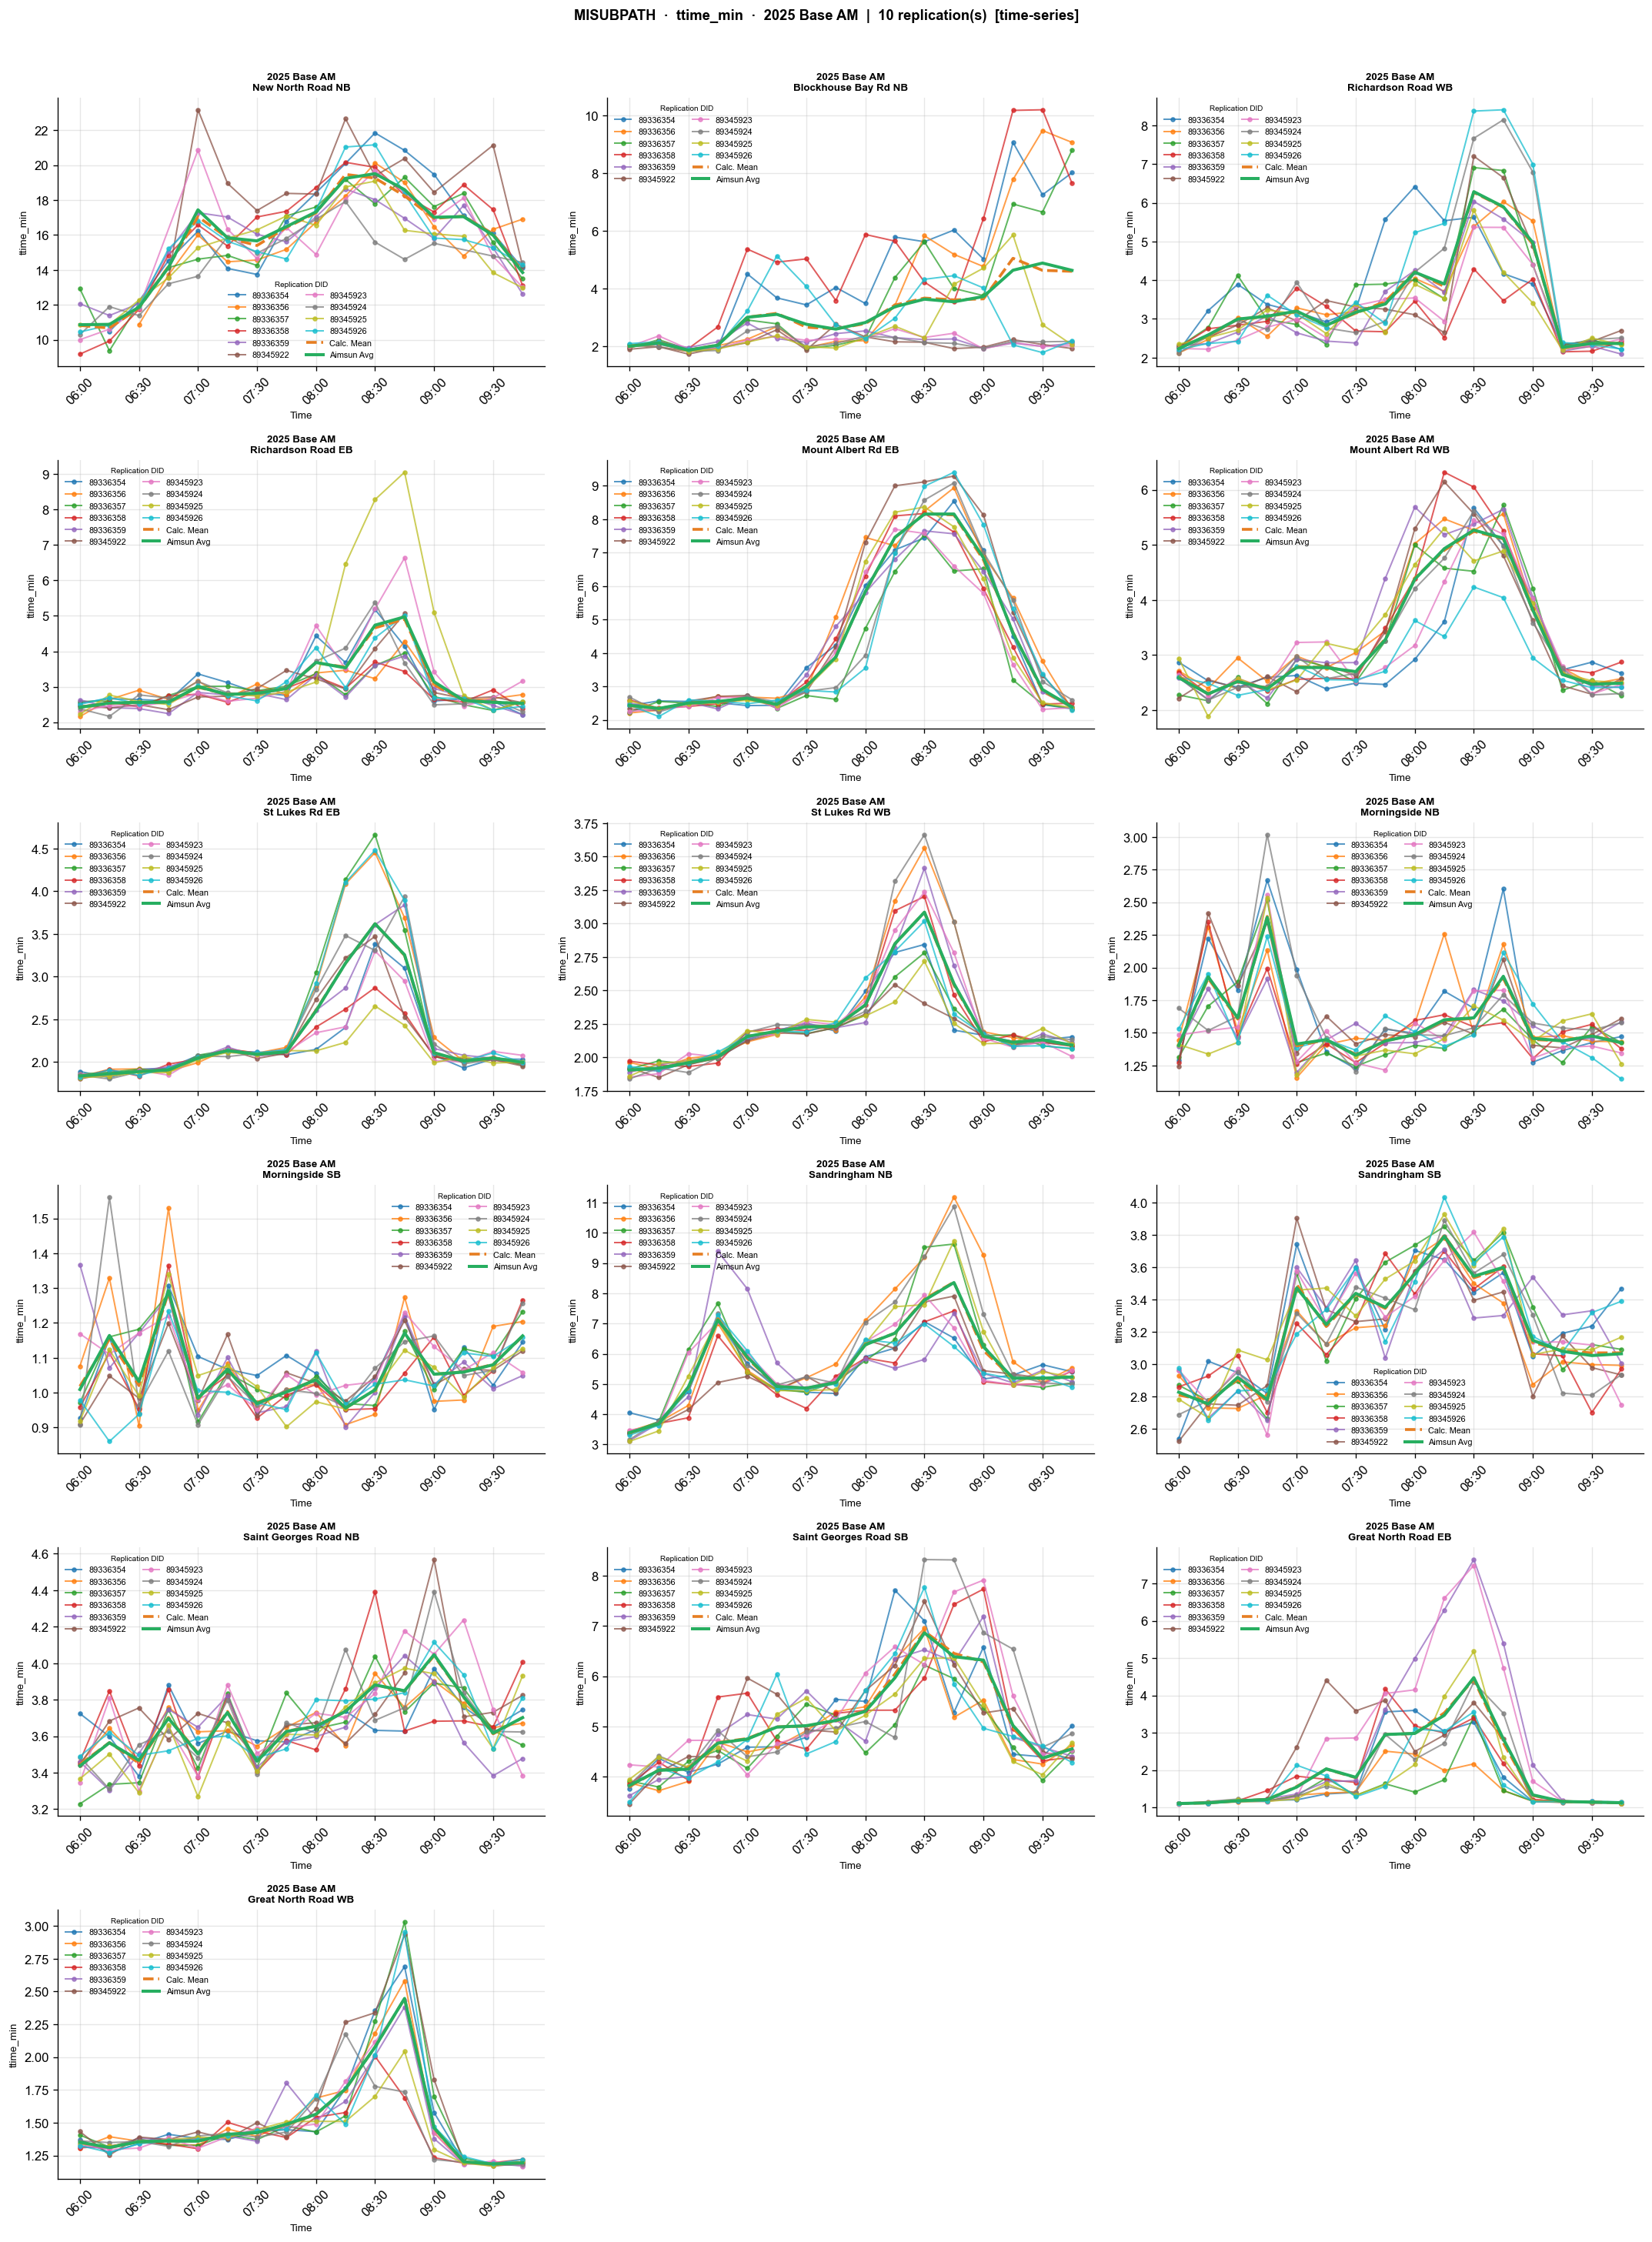

  MISUBPATH.ttime_min [2025 Base AM] — 16 panel(s), 10 replication(s) [time-series]

[2/4] MISUBPATH · ttime_min · 2025 Base PM


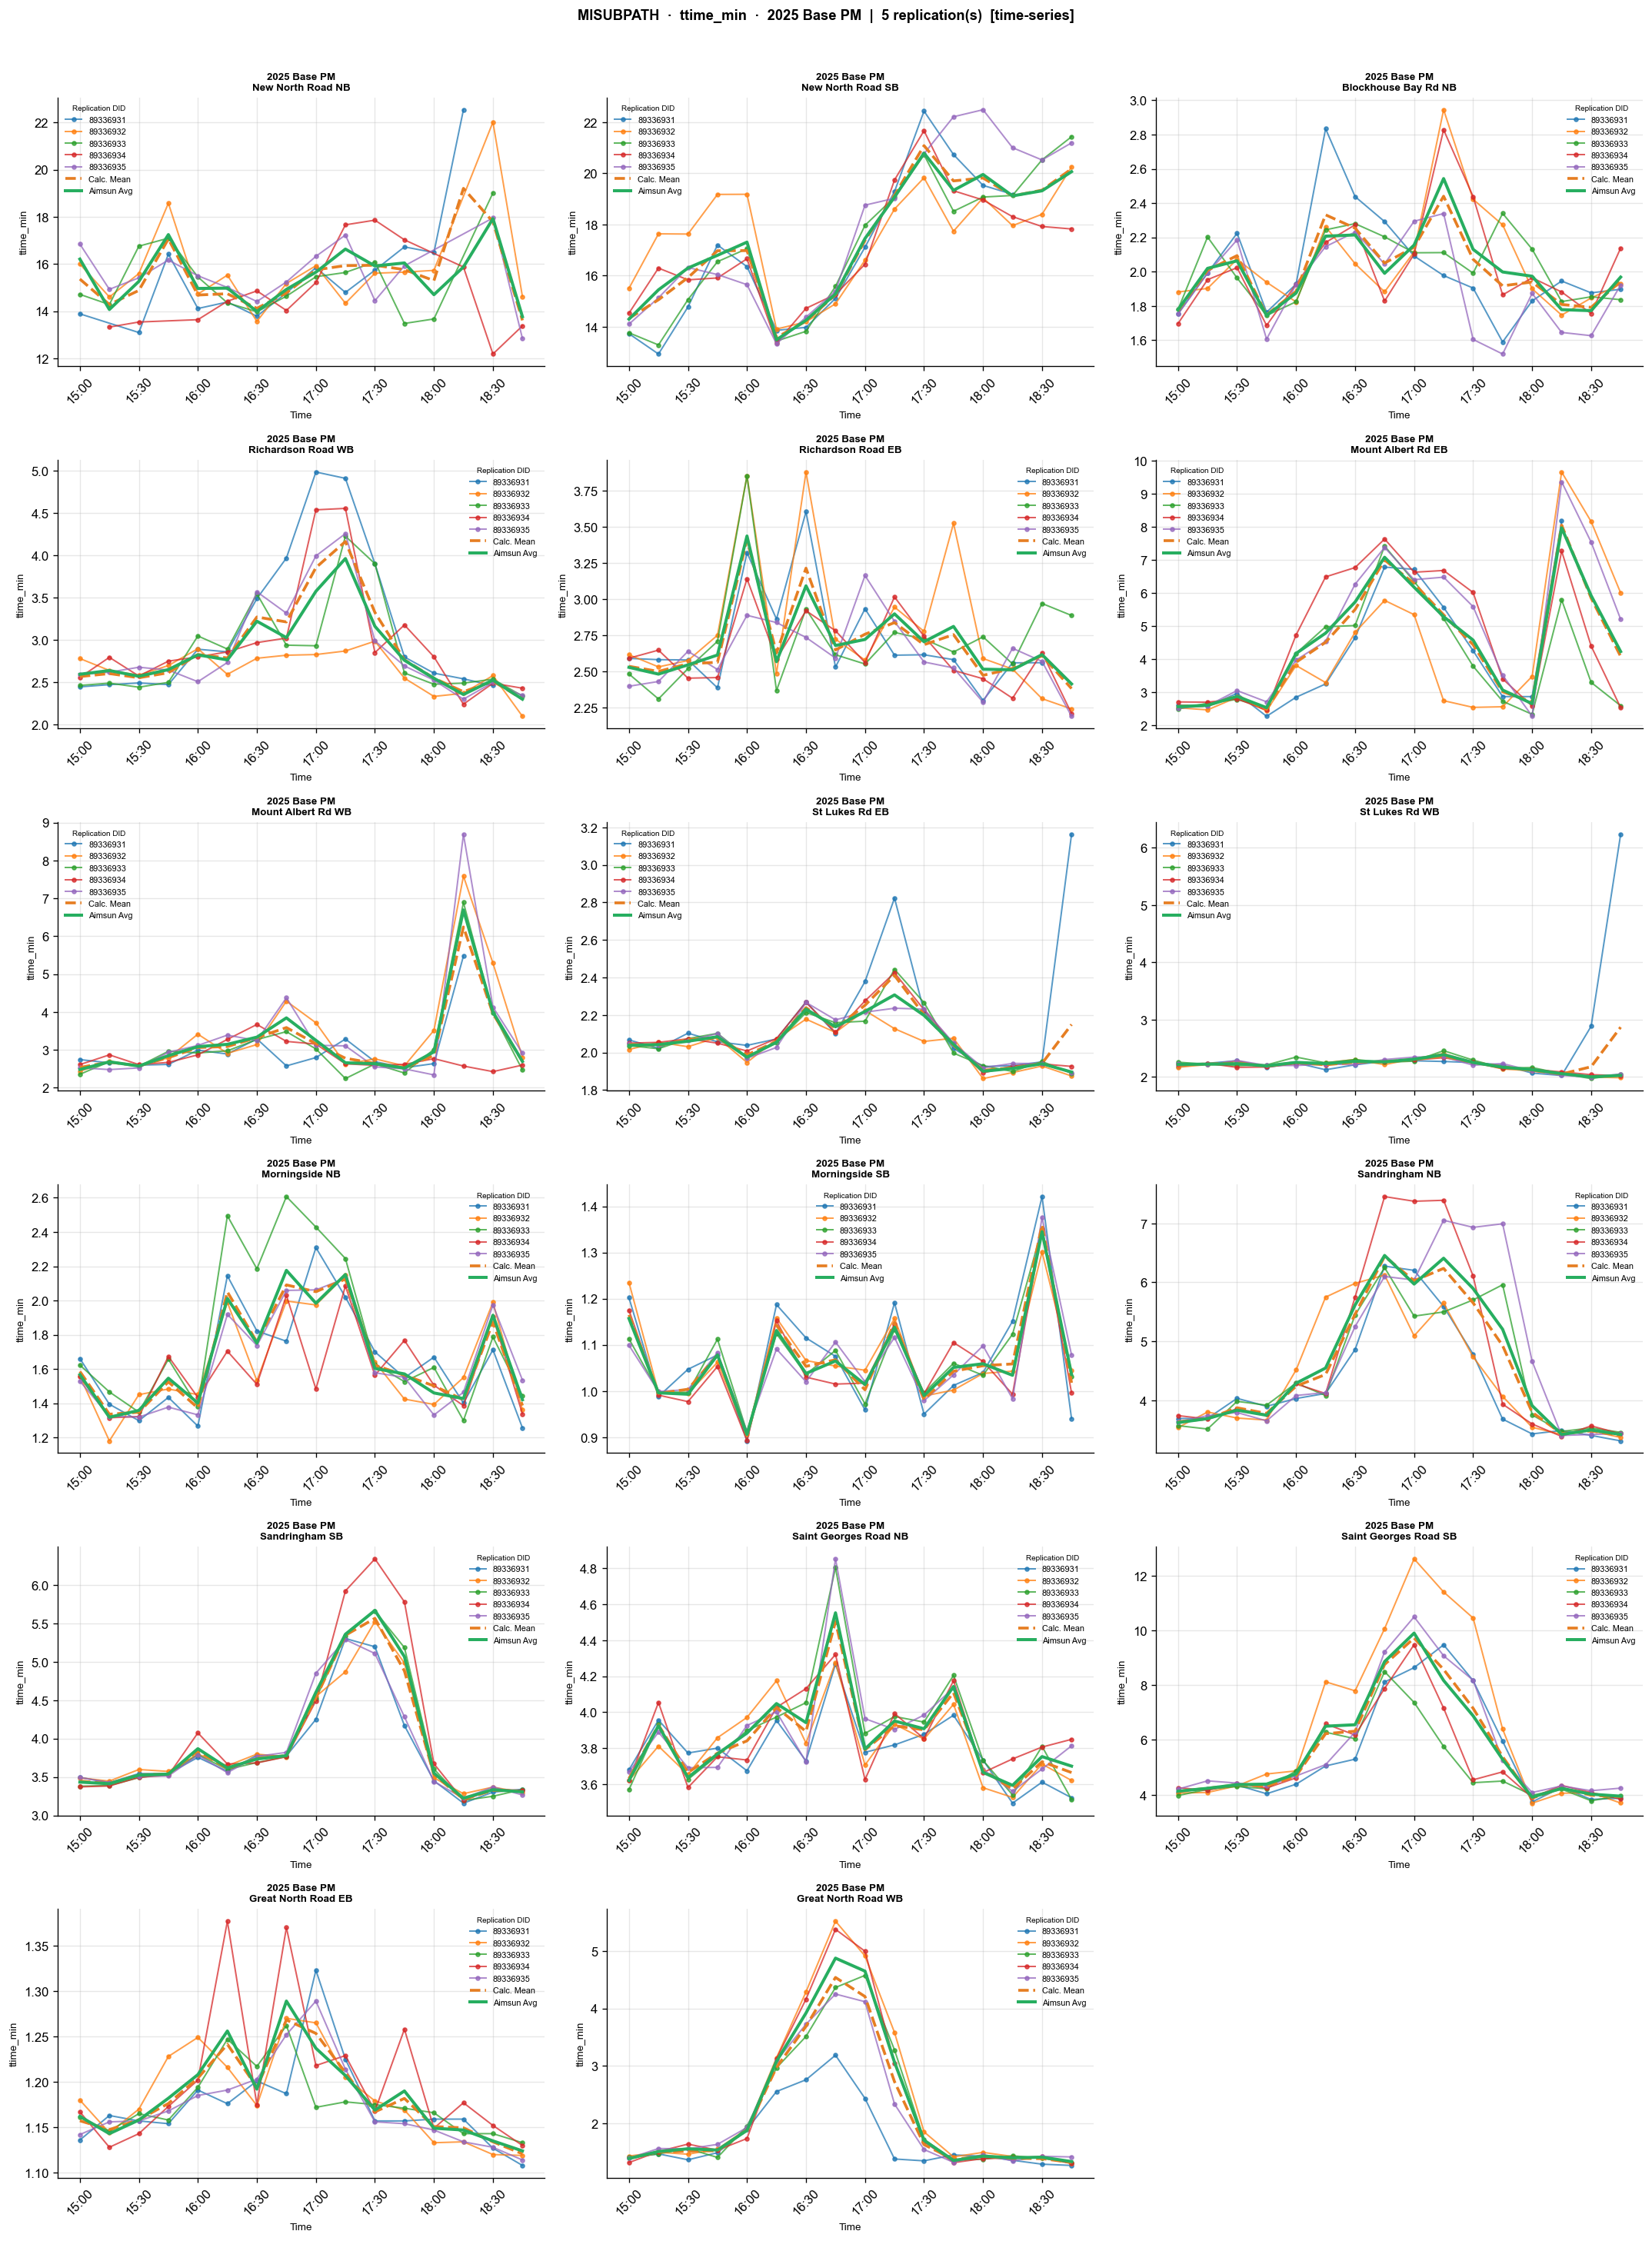

  MISUBPATH.ttime_min [2025 Base PM] — 17 panel(s), 5 replication(s) [time-series]

[3/4] MISYS · vWait · 2025 Base AM
  [MISYS] oid == replication_id detected — grouping by experiment+eid only.


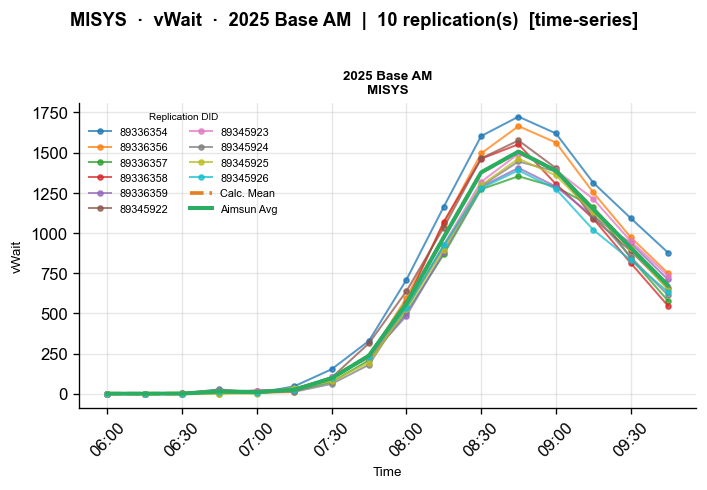

  MISYS.vWait [2025 Base AM] — 1 panel(s), 10 replication(s) [time-series]

[4/4] MISYS · vWait · 2025 Base PM
  [MISYS] oid == replication_id detected — grouping by experiment+eid only.


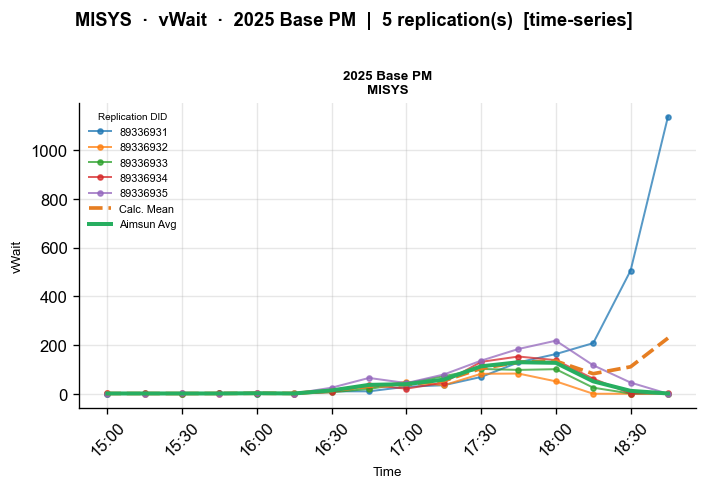

  MISYS.vWait [2025 Base PM] — 1 panel(s), 5 replication(s) [time-series]



In [35]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.cm as cm
import math

plt.rcParams.update({
    "font.family": "Arial",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "figure.dpi": 120,
})

def _fmt_hhmm(seconds):
    h, r = divmod(int(seconds), 3600)
    return f"{h:02d}:{r // 60:02d}"

def _oid_label(oid, eid):
    if oid in PLOT_OID_LABELS:
        return PLOT_OID_LABELS[oid]
    return f"{eid}  [{oid}]" if pd.notna(eid) else str(oid)

def _plot_config(cfg):
    """Produce one figure for a single PLOT_CONFIGS entry."""
    table       = cfg["table"]
    metric      = cfg["metric"]
    dids        = cfg.get("dids")
    eids        = cfg.get("eids")
    experiments = cfg.get("experiments")

    # ── Validate ─────────────────────────────────────────────────────────────
    if table not in dfs:
        raise ValueError(
            f"Table '{table}' was not extracted. "
            f"Add it to TABLES and re-run Extract. Extracted: {list(dfs.keys())}"
        )
    df = dfs[table]

    if metric not in df.columns:
        numeric_cols = [c for c in df.columns if df[c].dtype in ["float64", "int64"]]
        raise ValueError(
            f"Metric '{metric}' not found in {table}.\n"
            f"Available numeric columns: {numeric_cols}"
        )

    # ── Prepare Aimsun average data for this table (if available) ────────────
    avg_base = pd.DataFrame()
    if table in avgs and not avgs[table].empty and metric in avgs[table].columns:
        avg_base = avgs[table].copy()
        avg_base["eid"] = avg_base["eid"].fillna(table)

    # ── Filter replications ───────────────────────────────────────────────────
    plot_df = df.copy()

    # Fill null eids so groupby doesn't silently drop those rows
    plot_df["eid"] = plot_df["eid"].fillna(table)

    if experiments:
        missing_exp = [e for e in experiments if e not in plot_df["experiment"].values]
        if missing_exp:
            print(f"  Warning [{table}]: experiments not found: {missing_exp}")
            print(f"  Available experiments: {sorted(plot_df['experiment'].unique())}")
        plot_df = plot_df[plot_df["experiment"].isin(experiments)]

    if dids:
        missing = [d for d in dids if d not in plot_df["replication_id"].values]
        if missing:
            print(f"  Warning [{table}]: replication IDs not found: {missing}")
        plot_df = plot_df[plot_df["replication_id"].isin(dids)]

    if eids:
        missing_eids = [e for e in eids if e not in plot_df["eid"].values]
        if missing_eids:
            print(f"  Warning [{table}]: eids not found: {missing_eids}")
            print(f"  Available eids: {sorted(plot_df['eid'].dropna().unique())}")
        plot_df = plot_df[plot_df["eid"].isin(eids)]

    plot_df = plot_df.dropna(subset=[metric])

    if plot_df.empty:
        print(f"  Skipping '{table}.{metric}' — no data after filtering.")
        return

    # ── Detect interval vs summary mode ──────────────────────────────────────
    has_intervals = (plot_df["ent"] > 0).any()
    if has_intervals:
        plot_df = plot_df[plot_df["ent"] > 0].copy()
        plot_df["_time_s"] = plot_df["from_time"] + (plot_df["ent"] - 1) * 900

    # ── Auto-detect tables where oid == did (e.g. MISYS) ─────────────────────
    # In these tables the oid carries no object identity — grouping by it would
    # create one subplot per replication instead of one subplot per object.
    # When detected, group by (experiment, eid) only so all replications share
    # the same subplot as separate series.
    oid_equals_did = (plot_df["oid"] == plot_df["replication_id"]).all()
    if oid_equals_did:
        group_cols = ["experiment", "eid"]
        print(f"  [{table}] oid == replication_id detected — grouping by experiment+eid only.")
    else:
        group_cols = ["experiment", "eid", "oid"]

    # ── Colour palette ────────────────────────────────────────────────────────
    all_rep_ids = sorted(plot_df["replication_id"].unique())
    n_reps = len(all_rep_ids)
    palette = cm.tab10.colors if n_reps <= 10 else cm.tab20.colors
    rep_color = {rid: palette[i % len(palette)] for i, rid in enumerate(all_rep_ids)}
    MEAN_COLOR    = "#e67e22"   # orange dashed  — calculated mean of replications
    AIMSUN_COLOR  = "#27ae60"   # green solid    — Aimsun model average (type=2)

    # ── Layout ────────────────────────────────────────────────────────────────
    groups = list(plot_df.groupby(group_cols, sort=True))
    n_plots = len(groups)
    if n_plots == 0:
        print(f"  Skipping '{table}.{metric}' — no groups to plot.")
        return

    n_cols = min(n_plots, 3)
    n_rows = math.ceil(n_plots / n_cols)
    fig, axes = plt.subplots(n_rows, n_cols,
                              figsize=(6 * n_cols, 4 * n_rows),
                              squeeze=False)
    axes_flat = [axes[r][c] for r in range(n_rows) for c in range(n_cols)]

    for ax_i, (group_key, grp) in enumerate(groups):
        ax = axes_flat[ax_i]
        rep_ids = sorted(grp["replication_id"].unique())

        # Unpack group key depending on whether oid is included
        if oid_equals_did:
            exp, eid = group_key
            subplot_title = f"{exp}\n{eid}"
        else:
            exp, eid, oid = group_key
            subplot_title = f"{exp}\n{_oid_label(oid, eid)}"

        if has_intervals:
            # Individual replication lines
            for rep_id in rep_ids:
                rep_data = grp[grp["replication_id"] == rep_id].sort_values("_time_s")
                ax.plot(rep_data["_time_s"].values,
                        rep_data[metric].values,
                        color=rep_color[rep_id], linewidth=1.2, alpha=0.75,
                        marker="o", markersize=3,
                        label=str(rep_id))

            # Calculated mean of replications (orange dashed)
            mean_series = (
                grp.groupby("_time_s")[metric].mean()
                .reset_index().sort_values("_time_s")
            )
            ax.plot(mean_series["_time_s"], mean_series[metric],
                    color=MEAN_COLOR, linewidth=2.2, linestyle="--",
                    zorder=5, label="Calc. Mean")

            # Aimsun model average (green solid)
            if not avg_base.empty:
                _avg = avg_base[avg_base["experiment"] == exp]
                if eids:
                    _avg = _avg[_avg["eid"].isin(eids)]
                if not oid_equals_did:
                    _avg = _avg[_avg["oid"] == oid]
                _avg = _avg[_avg["ent"] > 0].copy()
                if not _avg.empty:
                    _avg["_time_s"] = _avg["from_time"] + (_avg["ent"] - 1) * 900
                    _avg = _avg.sort_values("_time_s")
                    ax.plot(_avg["_time_s"], _avg[metric],
                            color=AIMSUN_COLOR, linewidth=2.4, linestyle="-",
                            zorder=6, label="Aimsun Avg")

            # Tick every 30 minutes (1800 seconds)
            ax.xaxis.set_major_locator(mticker.MultipleLocator(1800))
            ax.xaxis.set_major_formatter(
                mticker.FuncFormatter(lambda v, _: _fmt_hhmm(v))
            )
            ax.tick_params(axis="x", labelrotation=45)
            ax.set_xlabel("Time", fontsize=8)

        else:
            # Summary bar chart
            for i, rep_id in enumerate(rep_ids):
                rep_data = grp[grp["replication_id"] == rep_id]
                y_val = rep_data[metric].values[0] if not rep_data.empty else float("nan")
                ax.bar(i, y_val, color=rep_color[rep_id], alpha=0.8,
                       label=str(rep_id), width=0.6)

            # Calculated mean (orange dashed)
            mean_val = grp[metric].mean()
            ax.axhline(mean_val, color=MEAN_COLOR, linewidth=1.8, linestyle="--",
                       zorder=5, label=f"Calc. Mean: {mean_val:.3f}")

            # Aimsun model average (green solid)
            if not avg_base.empty:
                _avg = avg_base[avg_base["experiment"] == exp]
                if eids:
                    _avg = _avg[_avg["eid"].isin(eids)]
                if not oid_equals_did:
                    _avg = _avg[_avg["oid"] == oid]
                _avg = _avg[_avg["ent"] == 0]
                if not _avg.empty:
                    aimsun_val = _avg[metric].dropna().mean()
                    if not pd.isna(aimsun_val):
                        ax.axhline(aimsun_val, color=AIMSUN_COLOR, linewidth=1.8, linestyle="-",
                                   zorder=6, label=f"Aimsun Avg: {aimsun_val:.3f}")

            ax.set_xticks(range(len(rep_ids)))
            ax.set_xticklabels([str(r) for r in rep_ids],
                                rotation=45, ha="right", fontsize=7)
            ax.set_xlabel("Replication DID", fontsize=8)

        ax.set_title(subplot_title, fontsize=8, fontweight="bold")
        ax.set_ylabel(metric, fontsize=8)
        ax.legend(fontsize=6.5, frameon=False,
                  ncol=2 if n_reps > 7 else 1,
                  title="Replication DID", title_fontsize=6)

    for ax_i in range(n_plots, len(axes_flat)):
        axes_flat[ax_i].set_visible(False)

    mode_label = "time-series" if has_intervals else "summary"
    exp_label  = ", ".join(experiments) if experiments else "all experiments"
    fig.suptitle(
        f"{table}  ·  {metric}  ·  {exp_label}  |  {n_reps} replication(s)  [{mode_label}]",
        fontsize=11, fontweight="bold", y=1.01,
    )
    fig.tight_layout()
    plt.show()
    print(f"  {table}.{metric} [{exp_label}] — {n_plots} panel(s), {n_reps} replication(s) [{mode_label}]")

# ── Run all configs ───────────────────────────────────────────────────────────
print(f"Running {len(PLOT_CONFIGS)} plot config(s)...\n")
for i, cfg in enumerate(PLOT_CONFIGS):
    exp_label = ", ".join(cfg["experiments"]) if cfg.get("experiments") else "all experiments"
    print(f"[{i+1}/{len(PLOT_CONFIGS)}] {cfg['table']} · {cfg['metric']} · {exp_label}")
    _plot_config(cfg)
    print()

## Save

In [36]:
if not dfs:
    print("Nothing to save — run the Extract cell first.")
else:
    with pd.ExcelWriter(OUTPUT_FILE, engine="openpyxl") as writer:

        # --- Replications index (from first extracted table) ---
        first_df = next(iter(dfs.values()))
        rep_index = (
            first_df[["replication_id", "replication_name", "experiment",
                       "scenario", "seed", "date", "from_time", "duration"]]
            .drop_duplicates()
            .sort_values(["experiment", "replication_id"])
            .reset_index(drop=True)
        )
        rep_index.to_excel(writer, sheet_name="Replications", index=False)
        print(f"Replications sheet : {len(rep_index)} replication(s)")

        # --- One sheet per table × experiment ---
        # Sheet name format: "MISUBPATH - 2025 Base AM" (truncated to 31 chars)
        for table_name, df in dfs.items():
            for exp, grp in df.groupby("experiment"):
                raw_name  = f"{table_name} - {exp}"
                sheet_name = raw_name[:31]
                grp = grp.sort_values(["replication_id", "oid", "ent"]).reset_index(drop=True)
                grp.to_excel(writer, sheet_name=sheet_name, index=False)
                n_reps = grp["replication_id"].nunique()
                print(f"  Sheet '{sheet_name}' : {len(grp):,} rows  ({n_reps} rep(s))")

    print(f"\nSaved → {OUTPUT_FILE}")

Replications sheet : 15 replication(s)
  Sheet 'MISUBPATH - 2025 Base AM' : 20,400 rows  (10 rep(s))
  Sheet 'MISUBPATH - 2025 Base PM' : 10,200 rows  (5 rep(s))
  Sheet 'MISYS - 2025 Base AM' : 170 rows  (10 rep(s))
  Sheet 'MISYS - 2025 Base PM' : 85 rows  (5 rep(s))

Saved → C:\Users\IvanVelilla\Documents\Projects\Western LX\outputs\replication_extract.xlsx
